In [1]:
# 加载 devtools
library(devtools)

# 加载本地包（假设你 notebook 所在目录是 gamFactory 文件夹）
load_all(".")

Loading required package: usethis

ℹ Loading gamFactory


Exports from /Users/xuanzhan/Xuan/code/gamFactory/src/expsmooth.cpp:
   List expsmooth(NumericVector y, NumericMatrix Xi, NumericVector beta, NumericVector x0, int deriv)

Exports from /Users/xuanzhan/Xuan/code/gamFactory/src/mgks.cpp:
   List mgks(NumericMatrix y, arma::field<arma::mat> dist, NumericVector beta, int deriv)

/Users/xuanzhan/Xuan/code/gamFactory/src/RcppExports.cpp updated.
/Users/xuanzhan/Xuan/code/gamFactory/R/RcppExports.R updated.


ℹ Re-compiling gamFactory (debug build)



── R CMD INSTALL ───────────────────────────────────────────────────────────────
* installing *source* package ‘gamFactory’ ...
** using staged installation
** libs
using C++ compiler: ‘Apple clang version 17.0.0 (clang-1700.0.13.3)’
using SDK: ‘MacOSX15.4.sdk’
clang++ -std=gnu++17 -I"/opt/homebrew/Cellar/r/4.4.3_1/lib/R/include" -DNDEBUG  -I'/opt/homebrew/lib/R/4.4/site-library/Rcpp/include' -I'/opt/homebrew/lib/R/4.4/site-library/RcppArmadillo/include' -I/opt/homebrew/opt/gettext/include -I/opt/homebrew/opt/readline/include -I/opt/homebrew/opt/xz/include -I/opt/homebrew/include    -fPIC  -g -O2  -UNDEBUG -Wall -pedantic -g -O0 -fdiagnostics-color=always  -c RcppExports.cpp -o RcppExports.o
clang++ -std=gnu++17 -I"/opt/homebrew/Cellar/r/4.4.3_1/lib/R/include" -DNDEBUG  -I'/opt/homebrew/lib/R/4.4/site-library/Rcpp/include' -I'/opt/homebrew/lib/R/4.4/site-library/RcppArmadillo/include' -I/opt/homebrew/opt/gettext/include -I/opt/homebrew/opt/readline/include -I/opt/homebrew/opt/xz/includ

Loading required package: mgcv

Loading required package: nlme

This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

Loading required package: matrixStats



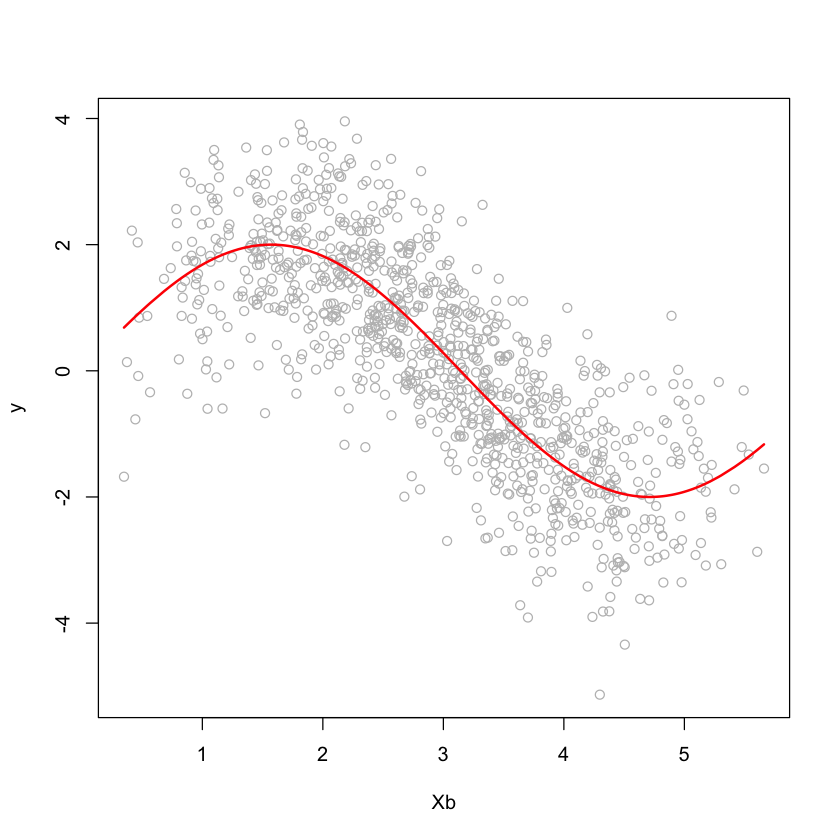

In [8]:
set.seed(6436)
n <- 1000; p <- 3; b <- 1:p

X <- matrix(runif(p * n), ncol = p)
Xb <- X %*% b
f_true <- 2 * sin(Xb)
y <- f_true + rnorm(n)
dat <- data.frame(y = y)
dat$X <- X

plot(Xb, y, col = "grey")
lines(sort(Xb), f_true[order(X %*% b)], col = "red", lwd = 2)

In [3]:
fit <- gam_nl(list(y ~ s_nest(X, trans = trans_linear()), ~ 1),
              data = dat, family = fam_gaussian())

In [4]:
summary(fit)


Family: gaussian_nl 
Link function: identity loginva(0.01) 

Formula:
y ~ s_nest(X, trans = trans_linear())
~1

Parametric coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    0.44690    0.05862   7.624 2.46e-14 ***
(Intercept).1 -0.02906    0.02260  -1.286    0.199    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
            edf Ref.df Chi.sq p-value    
s_nest(X) 8.269  8.783   1897  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


-REML = 1426.2  Scale est. = 1         n = 1000


In [5]:
AIC(fit)

[1] 2821.816

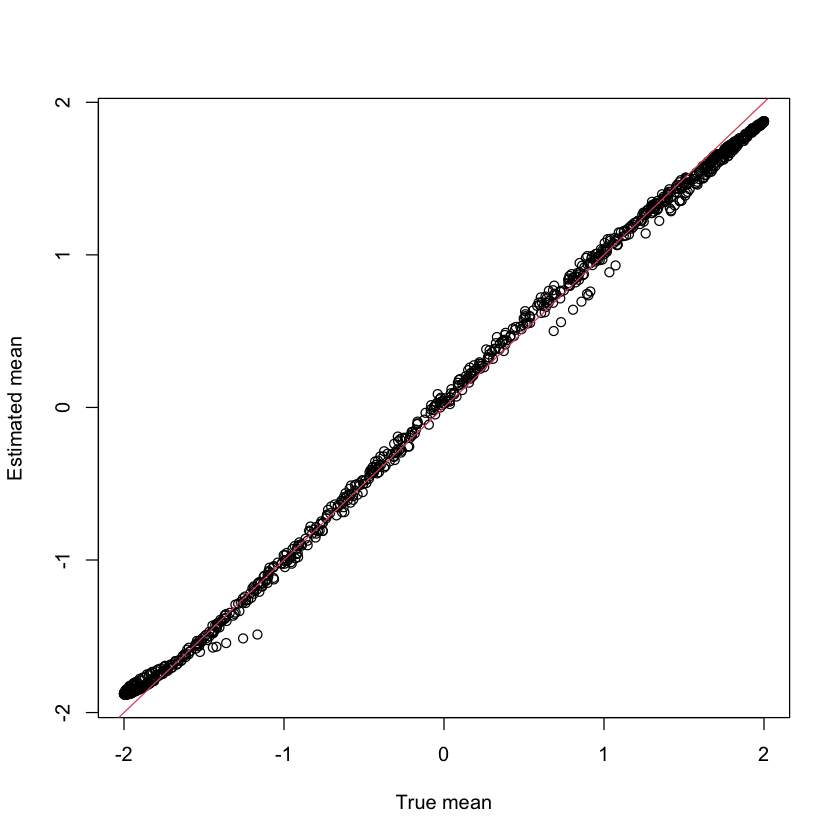

In [6]:
f_hat <- predict(fit)[ , 1]
plot(f_true, f_hat, xlab = "True mean", ylab = "Estimated mean")
abline(0, 1, col = 2)